
# V1 — RUGD In-domain Vegetation-specific Evaluation

This notebook is rebuilt from the verified directory/model logic in the older
`vegetation_direct_inference_with_ROD_latest` notebook.

It evaluates the four **RUGD-trained** binary segmentation checkpoints on the
existing **RUGD test split** and reports:

- Grass Ground Recall
- Tree Non-ground Recall
- Bush Non-ground Recall
- Bush Ground Leakage
- Vegetation Balanced Score (VBS)
- Vegetation Boundary F1

The original RUGD RGB semantic labels are used only to identify grass/tree/bush
regions. The models themselves remain binary ground/non-ground models.

### Evaluation convention
- `0 = non-ground`
- `1 = ground`
- `255 = ignore`
- Main metrics are aggregated from **global pixel counts across the full test set**
- ROD retains its own resize/pad + normalization pipeline from the original notebook


In [1]:

# 1. Install dependencies and clone official ROD repository

!pip -q install segmentation-models-pytorch albumentations

import os
import sys

ROD_REPO = "/content/offroad_roadseg"

if not os.path.exists(ROD_REPO):
    !git clone --depth 1 https://github.com/ict-ans-617/offroad_roadseg.git {ROD_REPO}

if ROD_REPO not in sys.path:
    sys.path.insert(0, ROD_REPO)

print("ROD repository:", ROD_REPO)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:00
Cloning into '/content/offroad_roadseg'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 80 (delta 17), reused 78 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 4.32 MiB | 16.51 MiB/s, done.
Resolving deltas: 100% (17/17), done.
ROD repository: /content/offroad_roadseg


In [2]:

# 2. Imports and device

from pathlib import Path
from typing import Dict, Tuple
from collections import defaultdict
import json
import time
import shutil
import urllib.request
import zipfile
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:

# 3. Mount Drive and configure paths

from google.colab import drive
drive.mount("/content/drive")

# -------------------------
# User-provided paths
# -------------------------
RUGD_RAW_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/raw/RUGD.zip"
)

RUGD_PROCESSED_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/processed/RUGD_processed.zip"
)

CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "unet_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "segformer_b0_rugd_binary_ground_best_20epochs.pth"
    ),
    "ROD": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "rod_rugd_binary_ground_best_20epochs.pth"
    ),
}

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/IRP/05_vegetation_evaluation/01_rugd_indomain/"
)

# -------------------------
# Local extraction paths
# -------------------------
RUGD_RAW_EXTRACT_ROOT = Path("/content/RUGD_raw")
RUGD_RAW_ROOT = RUGD_RAW_EXTRACT_ROOT / "RUGD"

# IMPORTANT: this follows the verified structure from the old notebook.
# RUGD_processed.zip contains content/RUGD_processed internally.
RUGD_PROCESSED_ROOT = Path("/content/content/RUGD_processed")

RUGD_IMAGE_ROOT = (
    RUGD_RAW_ROOT
    / "RUGD_frames-with-annotations"
    / "RUGD_frames-with-annotations"
)

RUGD_MASK_ROOT = (
    RUGD_RAW_ROOT
    / "RUGD_annotations"
    / "RUGD_annotations"
)

IMAGE_SIZE = (512, 512)
BATCH_SIZE = 4
NUM_WORKERS = 2

IGNORE_INDEX = 255
NON_GROUND_ID = 0
GROUND_ID = 1

BOUNDARY_TOLERANCE = 3
SAVE_PREDICTIONS = True

# Debug only:
# set e.g. 50 to test the pipeline quickly; use None for formal evaluation.
MAX_TEST_IMAGES = None

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Output:", OUTPUT_ROOT)


Mounted at /content/drive
Output: /content/drive/MyDrive/IRP/05_vegetation_evaluation/01_rugd_indomain


In [4]:

# 4. Extract RUGD using the VERIFIED old-notebook structure

def extract_zip(zip_path: Path, output_root: Path):
    if not zip_path.exists():
        raise FileNotFoundError(f"Zip file does not exist: {zip_path}")

    output_root.mkdir(parents=True, exist_ok=True)

    print(f"Extracting: {zip_path}")
    print(f"To:         {output_root}")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(output_root)

    print("Extraction complete.\n")


# Raw RUGD
if not RUGD_RAW_ROOT.exists():
    extract_zip(RUGD_RAW_ZIP, RUGD_RAW_EXTRACT_ROOT)
else:
    print("RUGD raw data already extracted:", RUGD_RAW_ROOT)


# Processed RUGD
# The old working code showed that this ZIP expands to:
# /content/content/RUGD_processed/
if not RUGD_PROCESSED_ROOT.exists():
    extract_zip(RUGD_PROCESSED_ZIP, Path("/content"))
else:
    print("RUGD processed data already extracted:", RUGD_PROCESSED_ROOT)


required_paths = {
    "RUGD raw root": RUGD_RAW_ROOT,
    "RUGD original image root": RUGD_IMAGE_ROOT,
    "RUGD original RGB mask root": RUGD_MASK_ROOT,
    "RUGD processed root": RUGD_PROCESSED_ROOT,
    "RUGD processed test images": RUGD_PROCESSED_ROOT / "images" / "test",
}

print("\nPATH CHECK")
print("=" * 100)

for name, path in required_paths.items():
    print(f"{name:32s} | exists={path.exists()} | {path}")

missing = [p for p in required_paths.values() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required paths:\n" + "\n".join(str(p) for p in missing)
    )


print("\nCHECKPOINT CHECK")
print("=" * 100)

for name, path in CHECKPOINTS.items():
    print(f"{name:14s} | exists={path.exists()} | {path}")

missing_ckpts = [p for p in CHECKPOINTS.values() if not p.exists()]
if missing_ckpts:
    raise FileNotFoundError(
        "Missing checkpoints:\n" + "\n".join(str(p) for p in missing_ckpts)
    )


Extracting: /content/drive/MyDrive/IRP/01_data/raw/RUGD.zip
To:         /content/RUGD_raw
Extraction complete.

Extracting: /content/drive/MyDrive/IRP/01_data/processed/RUGD_processed.zip
To:         /content
Extraction complete.


PATH CHECK
RUGD raw root                    | exists=True | /content/RUGD_raw/RUGD
RUGD original image root         | exists=True | /content/RUGD_raw/RUGD/RUGD_frames-with-annotations/RUGD_frames-with-annotations
RUGD original RGB mask root      | exists=True | /content/RUGD_raw/RUGD/RUGD_annotations/RUGD_annotations
RUGD processed root              | exists=True | /content/content/RUGD_processed
RUGD processed test images       | exists=True | /content/content/RUGD_processed/images/test

CHECKPOINT CHECK
U-Net          | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
DeepLabV3+     | exists=True | /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_bi

In [5]:

# 5. RUGD semantic colours and binary mapping
#
# Same mapping as the verified old notebook.

RUGD_COLOR_TO_ID = {
    (0, 0, 0): 0,
    (108, 64, 20): 1,
    (255, 229, 204): 2,
    (0, 102, 0): 3,       # grass
    (0, 255, 0): 4,       # tree
    (0, 153, 153): 5,
    (0, 128, 255): 6,
    (0, 0, 255): 7,
    (255, 255, 0): 8,
    (255, 0, 127): 9,
    (64, 64, 64): 10,
    (255, 128, 0): 11,
    (255, 0, 0): 12,
    (153, 76, 0): 13,
    (102, 102, 0): 14,
    (102, 0, 0): 15,
    (0, 255, 128): 16,
    (204, 153, 255): 17,
    (102, 0, 204): 18,
    (255, 153, 204): 19,  # bush
    (0, 102, 102): 20,
    (153, 204, 255): 21,
    (102, 255, 255): 22,
    (101, 101, 11): 23,
    (114, 85, 47): 24,
}

RUGD_CLASS_COLORS = {
    "grass": (0, 102, 0),
    "tree": (0, 255, 0),
    "bush": (255, 153, 204),
}

# Same binary mapping as the old code:
# water, sky, bridge, void -> ignore
RUGD_GROUND_ORIGINAL_IDS = {1, 2, 3, 10, 11, 13, 14, 23}
RUGD_IGNORE_ORIGINAL_IDS = {0, 6, 7, 22}

print("Vegetation colours:", RUGD_CLASS_COLORS)
print("Ground original IDs:", sorted(RUGD_GROUND_ORIGINAL_IDS))
print("Ignore original IDs:", sorted(RUGD_IGNORE_ORIGINAL_IDS))


Vegetation colours: {'grass': (0, 102, 0), 'tree': (0, 255, 0), 'bush': (255, 153, 204)}
Ground original IDs: [1, 2, 3, 10, 11, 13, 14, 23]
Ignore original IDs: [0, 6, 7, 22]


In [6]:

# 6. Build the RUGD TEST record list
#
# This directly reuses the filename logic from the old working notebook.
# No manifest.csv is required.

def build_rugd_original_mask_lookup(mask_root: Path) -> Dict[str, Path]:
    lookup = {}

    for mask_path in mask_root.rglob("*.png"):
        relative = mask_path.relative_to(mask_root)

        if len(relative.parts) < 2:
            continue

        sequence_name = relative.parts[0]

        # This is the key naming convention used by the processed dataset.
        processed_name = f"{sequence_name}_{mask_path.name}"

        if processed_name in lookup:
            raise RuntimeError(
                f"Duplicate processed RUGD name: {processed_name}"
            )

        lookup[processed_name] = mask_path

    if not lookup:
        raise RuntimeError(
            f"No RUGD RGB masks found under: {mask_root}"
        )

    return lookup


def build_rugd_test_records() -> pd.DataFrame:
    image_dir = RUGD_PROCESSED_ROOT / "images" / "test"

    if not image_dir.exists():
        raise FileNotFoundError(
            f"RUGD test image directory does not exist: {image_dir}"
        )

    if not RUGD_MASK_ROOT.exists():
        raise FileNotFoundError(
            f"RUGD original RGB label directory does not exist: {RUGD_MASK_ROOT}"
        )

    lookup = build_rugd_original_mask_lookup(RUGD_MASK_ROOT)

    image_paths = sorted(
        list(image_dir.glob("*.png"))
        + list(image_dir.glob("*.jpg"))
        + list(image_dir.glob("*.jpeg"))
    )

    if not image_paths:
        raise RuntimeError(
            f"No RUGD test images found in: {image_dir}"
        )

    rows = []
    missing = []

    for image_path in image_paths:
        original_mask = lookup.get(image_path.name)

        if original_mask is None:
            missing.append(image_path.name)
            continue

        rows.append({
            "dataset": "RUGD",
            "processed_name": image_path.name,
            "image_path": str(image_path),
            "original_rgb_mask_path": str(original_mask),
        })

    if missing:
        print(
            f"Warning: {len(missing)} RUGD test images "
            "could not be mapped to original semantic masks."
        )
        print("First 10 missing names:", missing[:10])

    if not rows:
        raise RuntimeError("No RUGD test records were created.")

    records = pd.DataFrame(rows)

    if MAX_TEST_IMAGES is not None:
        records = records.head(MAX_TEST_IMAGES).copy()

    return records.reset_index(drop=True)


rugd_records = build_rugd_test_records()

print("RUGD test records:", len(rugd_records))
display(rugd_records.head())

if MAX_TEST_IMAGES is None:
    print("Formal full-test evaluation mode.")
else:
    print(f"DEBUG MODE: only first {len(rugd_records)} images are used.")


RUGD test records: 1482


,dataset,processed_name,image_path,original_rgb_mask_path
0,RUGD,creek_creek_00001.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...
1,RUGD,creek_creek_00006.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...
2,RUGD,creek_creek_00011.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...
3,RUGD,creek_creek_00016.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...
4,RUGD,creek_creek_00021.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...


Formal full-test evaluation mode.


In [7]:

# 7. RGB semantic GT -> binary GT and vegetation regions

def read_rgb(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"))


def color_region(
    mask_rgb: np.ndarray,
    color: Tuple[int, int, int],
) -> np.ndarray:
    return np.all(
        mask_rgb == np.asarray(color, dtype=np.uint8),
        axis=-1,
    )


def rgb_to_rugd_original_id(
    mask_rgb: np.ndarray,
) -> np.ndarray:
    output = np.full(
        mask_rgb.shape[:2],
        IGNORE_INDEX,
        dtype=np.uint8,
    )

    for color, class_id in RUGD_COLOR_TO_ID.items():
        output[color_region(mask_rgb, color)] = class_id

    return output


def rugd_rgb_to_binary(
    mask_rgb: np.ndarray,
) -> np.ndarray:
    original_id = rgb_to_rugd_original_id(mask_rgb)

    output = np.full(
        original_id.shape,
        IGNORE_INDEX,
        dtype=np.uint8,
    )

    valid = original_id != IGNORE_INDEX
    ground = np.isin(
        original_id,
        list(RUGD_GROUND_ORIGINAL_IDS),
    )
    ignore = np.isin(
        original_id,
        list(RUGD_IGNORE_ORIGINAL_IDS),
    )

    output[valid & ~ground & ~ignore] = NON_GROUND_ID
    output[ground] = GROUND_ID
    output[ignore] = IGNORE_INDEX

    return output


def extract_vegetation_regions(
    original_rgb_mask: np.ndarray,
) -> Dict[str, np.ndarray]:

    grass = color_region(
        original_rgb_mask,
        RUGD_CLASS_COLORS["grass"],
    )

    tree = color_region(
        original_rgb_mask,
        RUGD_CLASS_COLORS["tree"],
    )

    bush = color_region(
        original_rgb_mask,
        RUGD_CLASS_COLORS["bush"],
    )

    return {
        "grass": grass,
        "tree": tree,
        "bush": bush,
        "vegetation": grass | tree | bush,
        "obstacle_vegetation": tree | bush,
    }


# Sanity check several samples
for _, row in rugd_records.head(5).iterrows():
    semantic_rgb = read_rgb(Path(row["original_rgb_mask_path"]))
    binary_gt = rugd_rgb_to_binary(semantic_rgb)
    regions = extract_vegetation_regions(semantic_rgb)

    print(
        row["processed_name"],
        "| GT values:", np.unique(binary_gt).tolist(),
        "| grass:", int(regions["grass"].sum()),
        "| tree:", int(regions["tree"].sum()),
        "| bush:", int(regions["bush"].sum()),
    )


creek_creek_00001.png | GT values: [0, 1, 255] | grass: 21364 | tree: 117950 | bush: 65155
creek_creek_00006.png | GT values: [0, 1, 255] | grass: 21243 | tree: 133196 | bush: 54794
creek_creek_00011.png | GT values: [0, 1, 255] | grass: 21920 | tree: 116463 | bush: 61491
creek_creek_00016.png | GT values: [0, 1, 255] | grass: 16378 | tree: 114275 | bush: 60924
creek_creek_00021.png | GT values: [0, 1, 255] | grass: 21141 | tree: 133576 | bush: 37297


In [8]:

# 8. Standard preprocessing for U-Net / DeepLabV3+ / SegFormer-B0
#
# Matches the old working inference notebook:
# direct resize to 512x512 + ImageNet normalization.

INFERENCE_TRANSFORM = A.Compose([
    A.Resize(
        height=IMAGE_SIZE[0],
        width=IMAGE_SIZE[1],
        interpolation=cv2.INTER_LINEAR,
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2(),
])


class InferenceDataset(Dataset):
    def __init__(self, records: pd.DataFrame):
        self.records = records.reset_index(drop=True)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records.iloc[index]
        image = read_rgb(Path(row["image_path"]))

        transformed = INFERENCE_TRANSFORM(image=image)
        tensor = transformed["image"].float()

        return {
            "image": tensor,
            "index": index,
            "original_height": image.shape[0],
            "original_width": image.shape[1],
        }


def make_loader(records: pd.DataFrame) -> DataLoader:
    return DataLoader(
        InferenceDataset(records),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


In [9]:

# 9. Build model architectures
#
# These definitions are taken from the old working notebook.

def build_unet() -> torch.nn.Module:
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=2,
    )


def build_deeplabv3plus() -> torch.nn.Module:
    return smp.DeepLabV3Plus(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=2,
    )


def build_segformer_b0() -> torch.nn.Module:
    return smp.Segformer(
        encoder_name="mit_b0",
        encoder_weights=None,
        in_channels=3,
        classes=2,
        activation=None,
    )


# ============================================================
# ROD: EfficientSAM-S encoder + SegHead decoder
# ============================================================

WEIGHTS_DIR = Path(ROD_REPO) / "efficient_sam" / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_ZIP = WEIGHTS_DIR / "efficient_sam_vits.pt.zip"
VITS_PATH = WEIGHTS_DIR / "efficient_sam_vits.pt"

if not VITS_PATH.exists():
    if not WEIGHTS_ZIP.exists():
        weights_url = (
            "https://github.com/yformer/EfficientSAM/raw/main/"
            "weights/efficient_sam_vits.pt.zip"
        )
        print("Downloading EfficientSAM-S weights...")
        urllib.request.urlretrieve(
            weights_url,
            WEIGHTS_ZIP,
        )

    with zipfile.ZipFile(WEIGHTS_ZIP, "r") as archive:
        archive.extractall(WEIGHTS_DIR)

if not VITS_PATH.exists():
    raise FileNotFoundError(
        f"EfficientSAM-S checkpoint not found: {VITS_PATH}"
    )


from efficient_sam.build_efficient_sam import build_efficient_sam_vits
from seg_decoder import SegHead


def load_rod_encoder(checkpoint_path: Path):
    checkpoint_path = Path(checkpoint_path).resolve()

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"EfficientSAM checkpoint not found: {checkpoint_path}"
        )

    efficient_sam_dir = Path(ROD_REPO) / "efficient_sam"

    expected_checkpoint = (
        efficient_sam_dir
        / "weights"
        / "efficient_sam_vits.pt"
    ).resolve()

    if checkpoint_path != expected_checkpoint:
        expected_checkpoint.parent.mkdir(
            parents=True,
            exist_ok=True,
        )
        shutil.copy2(
            checkpoint_path,
            expected_checkpoint,
        )

    previous_cwd = Path.cwd()

    try:
        os.chdir(efficient_sam_dir)
        efficient_sam_model = build_efficient_sam_vits()
    finally:
        os.chdir(previous_cwd)

    return efficient_sam_model.image_encoder


class ROD(torch.nn.Module):
    def __init__(
        self,
        checkpoint_path: Path,
        freeze: bool = True,
    ):
        super().__init__()

        self.encoder = load_rod_encoder(checkpoint_path)
        self.decoder = SegHead()
        self.freeze = freeze

        self.encoder_input_size = int(
            self.encoder.img_size
        )

        if self.freeze:
            for parameter in self.encoder.parameters():
                parameter.requires_grad = False
            self.encoder.eval()

    def train(self, mode: bool = True):
        super().train(mode)

        if self.freeze:
            self.encoder.eval()

        return self

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:

        output_size = x.shape[-2:]

        if x.shape[-2:] != (
            self.encoder_input_size,
            self.encoder_input_size,
        ):
            encoder_x = F.interpolate(
                x,
                size=(
                    self.encoder_input_size,
                    self.encoder_input_size,
                ),
                mode="bilinear",
                align_corners=False,
            )
        else:
            encoder_x = x

        if self.freeze:
            with torch.no_grad():
                features = self.encoder(
                    encoder_x.float()
                )
        else:
            features = self.encoder(
                encoder_x.float()
            )

        if torch.is_tensor(features):
            features = features.float()

        elif isinstance(features, (list, tuple)):
            features = [
                value.float()
                if torch.is_tensor(value)
                else value
                for value in features
            ]

        elif isinstance(features, dict):
            features = {
                key: (
                    value.float()
                    if torch.is_tensor(value)
                    else value
                )
                for key, value in features.items()
            }

        with torch.backends.cudnn.flags(enabled=False):
            logits = self.decoder(features)

        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )

        return logits


def build_rod() -> torch.nn.Module:
    return ROD(
        checkpoint_path=VITS_PATH,
        freeze=True,
    )


MODEL_BUILDERS = {
    "U-Net": build_unet,
    "DeepLabV3+": build_deeplabv3plus,
    "SegFormer-B0": build_segformer_b0,
    "ROD": build_rod,
}

print("Model builders ready.")


Model builders ready.


In [10]:

# 10. Checkpoint loader
#
# Strict loading is required for formal evaluation.

def extract_state_dict(checkpoint):
    if isinstance(checkpoint, torch.nn.Module):
        return checkpoint.state_dict()

    if not isinstance(checkpoint, dict):
        raise TypeError(
            f"Unsupported checkpoint object type: {type(checkpoint)}"
        )

    for key in [
        "state_dict",
        "model_state_dict",
        "model",
        "net",
        "weights",
    ]:
        value = checkpoint.get(key)

        if isinstance(value, dict):
            return value

    if checkpoint and all(
        isinstance(key, str)
        for key in checkpoint.keys()
    ):
        return checkpoint

    raise KeyError(
        "Could not locate a state_dict in checkpoint"
    )


def strip_prefixes(
    state_dict: Dict[str, torch.Tensor],
):
    prefixes = (
        "module.",
        "model.",
        "net.",
    )

    cleaned = {}

    for key, value in state_dict.items():
        new_key = key

        changed = True

        while changed:
            changed = False

            for prefix in prefixes:
                if new_key.startswith(prefix):
                    new_key = new_key[
                        len(prefix):
                    ]
                    changed = True

        cleaned[new_key] = value

    return cleaned


def load_model_checkpoint(
    model_name: str,
    checkpoint_path: Path,
) -> torch.nn.Module:

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            checkpoint_path
        )

    model = MODEL_BUILDERS[model_name]()

    # PyTorch 2.6+ defaults weights_only=True.
    # These checkpoints were created by this project and may contain
    # NumPy scalars / optimizer metadata in addition to the state_dict,
    # so explicitly load the trusted checkpoint with weights_only=False.
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    state_dict = strip_prefixes(
        extract_state_dict(checkpoint)
    )

    try:
        model.load_state_dict(
            state_dict,
            strict=True,
        )

        print(
            f"[OK] {model_name}: strict checkpoint load"
        )

    except RuntimeError as error:
        print("\nCheckpoint keys:")
        print(list(state_dict.keys())[:20])

        print("\nModel keys:")
        print(list(model.state_dict().keys())[:20])

        raise RuntimeError(
            f"{model_name} checkpoint does not strictly match "
            "the model definition. Evaluation stopped to avoid "
            "an invalid partial load."
        ) from error

    model = model.to(DEVICE)
    model.eval()

    return model


# Validate all model/checkpoint pairs now.
for model_name, checkpoint_path in CHECKPOINTS.items():
    model = load_model_checkpoint(
        model_name,
        checkpoint_path,
    )

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nAll checkpoints passed strict loading.")


[OK] U-Net: strict checkpoint load
[OK] DeepLabV3+: strict checkpoint load
[OK] SegFormer-B0: strict checkpoint load
[OK] ROD: strict checkpoint load

All checkpoints passed strict loading.


In [11]:

# 11. Unified output extraction + standard inference

def extract_logits(model_output):
    if hasattr(model_output, "logits"):
        return model_output.logits

    if isinstance(model_output, dict):
        for key in [
            "out",
            "logits",
            "pred",
            "prediction",
            "segmentation",
            "mask_logits",
        ]:
            if key in model_output:
                return model_output[key]

        raise KeyError(
            f"Unknown model output keys: "
            f"{list(model_output.keys())}"
        )

    if isinstance(model_output, (tuple, list)):
        return model_output[0]

    if not torch.is_tensor(model_output):
        raise TypeError(
            f"Unsupported model output type: "
            f"{type(model_output)}"
        )

    return model_output


@torch.inference_mode()
def infer_batch(
    model: torch.nn.Module,
    images: torch.Tensor,
    output_size: Tuple[int, int],
) -> torch.Tensor:

    images = images.to(
        DEVICE,
        non_blocking=True,
    )

    output = model(images)
    logits = extract_logits(output)

    if logits.shape[-2:] != output_size:
        logits = F.interpolate(
            logits,
            size=output_size,
            mode="bilinear",
            align_corners=False,
        )

    return torch.argmax(
        logits,
        dim=1,
    ).cpu()


In [12]:

# 12. ROD-specific preprocessing and output restoration
#
# Kept separate because the old working ROD notebook used:
# aspect-ratio-preserving resize/pad + ROD pixel mean/std.

ROD_PIXEL_MEAN = np.array(
    [123.675, 116.28, 103.53],
    dtype=np.float32,
)

ROD_PIXEL_STD = np.array(
    [58.395, 57.12, 57.375],
    dtype=np.float32,
)


def rod_resize_pad(
    image_rgb: np.ndarray,
    size: int = 512,
):
    original_h, original_w = image_rgb.shape[:2]

    scale = size / max(
        original_h,
        original_w,
    )

    new_h = int(round(original_h * scale))
    new_w = int(round(original_w * scale))

    resized = cv2.resize(
        image_rgb,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR,
    )

    top = (size - new_h) // 2
    bottom = size - new_h - top

    left = (size - new_w) // 2
    right = size - new_w - left

    padded = cv2.copyMakeBorder(
        resized,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=(0, 0, 0),
    )

    meta = {
        "original_h": original_h,
        "original_w": original_w,
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
    }

    return padded, meta


def rod_normalize_image(
    image_rgb: np.ndarray,
) -> torch.Tensor:

    image = (
        image_rgb.astype(np.float32)
        - ROD_PIXEL_MEAN
    ) / ROD_PIXEL_STD

    return (
        torch.from_numpy(image)
        .permute(2, 0, 1)
        .contiguous()
    )


def restore_rod_prediction(
    padded_prediction: np.ndarray,
    meta: Dict[str, int],
) -> np.ndarray:

    top = meta["top"]
    left = meta["left"]

    new_h = meta["new_h"]
    new_w = meta["new_w"]

    cropped = padded_prediction[
        top:top + new_h,
        left:left + new_w,
    ]

    restored = cv2.resize(
        cropped,
        (
            meta["original_w"],
            meta["original_h"],
        ),
        interpolation=cv2.INTER_NEAREST,
    )

    return restored.astype(np.uint8)


@torch.inference_mode()
def infer_rod_image(
    model: torch.nn.Module,
    image_rgb: np.ndarray,
) -> np.ndarray:

    padded_image, meta = rod_resize_pad(
        image_rgb,
        size=IMAGE_SIZE[0],
    )

    tensor = (
        rod_normalize_image(
            padded_image
        )
        .unsqueeze(0)
        .float()
        .to(DEVICE)
    )

    output = model(tensor)
    logits = extract_logits(output)

    padded_prediction = (
        logits.argmax(dim=1)[0]
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    return restore_rod_prediction(
        padded_prediction,
        meta,
    )


In [13]:

# 13. Metric helpers

def safe_ratio(
    numerator: int,
    denominator: int,
):
    if denominator == 0:
        return np.nan

    return float(
        numerator / denominator
    )


def resize_nearest(
    array: np.ndarray,
    target_shape: Tuple[int, int],
) -> np.ndarray:

    target_h, target_w = target_shape

    if array.shape[:2] == (
        target_h,
        target_w,
    ):
        return array

    pil = Image.fromarray(array)

    resized = pil.resize(
        (target_w, target_h),
        resample=Image.Resampling.NEAREST,
    )

    return np.array(resized)


In [14]:

# 14. Vegetation metrics

def evaluate_vegetation_metrics(
    pred: np.ndarray,
    gt_binary: np.ndarray,
    regions: Dict[str, np.ndarray],
) -> Dict[str, float]:

    if pred.shape != gt_binary.shape:
        raise ValueError(
            f"Prediction/GT mismatch: "
            f"{pred.shape} vs {gt_binary.shape}"
        )

    valid = (
        gt_binary != IGNORE_INDEX
    )

    output = {}

    # -------------------------
    # Grass -> ground
    # -------------------------
    grass_roi = (
        regions["grass"]
        & valid
        & (gt_binary == GROUND_ID)
    )

    grass_pixels = int(
        grass_roi.sum()
    )

    grass_correct = int(
        (
            (pred == GROUND_ID)
            & grass_roi
        ).sum()
    )

    output["grass_pixels"] = grass_pixels
    output["grass_ground_correct"] = grass_correct

    output["grass_ground_recall"] = safe_ratio(
        grass_correct,
        grass_pixels,
    )

    # -------------------------
    # Tree -> non-ground
    # -------------------------
    tree_roi = (
        regions["tree"]
        & valid
        & (gt_binary == NON_GROUND_ID)
    )

    tree_pixels = int(
        tree_roi.sum()
    )

    tree_correct = int(
        (
            (pred == NON_GROUND_ID)
            & tree_roi
        ).sum()
    )

    output["tree_pixels"] = tree_pixels
    output["tree_non_ground_correct"] = tree_correct

    output["tree_non_ground_recall"] = safe_ratio(
        tree_correct,
        tree_pixels,
    )

    # -------------------------
    # Bush -> non-ground
    # -------------------------
    bush_roi = (
        regions["bush"]
        & valid
        & (gt_binary == NON_GROUND_ID)
    )

    bush_pixels = int(
        bush_roi.sum()
    )

    bush_correct = int(
        (
            (pred == NON_GROUND_ID)
            & bush_roi
        ).sum()
    )

    bush_leaked = int(
        (
            (pred == GROUND_ID)
            & bush_roi
        ).sum()
    )

    output["bush_pixels"] = bush_pixels
    output["bush_non_ground_correct"] = bush_correct
    output["bush_leaked_as_ground"] = bush_leaked

    output["bush_non_ground_recall"] = safe_ratio(
        bush_correct,
        bush_pixels,
    )

    output["bush_ground_leakage"] = safe_ratio(
        bush_leaked,
        bush_pixels,
    )

    # Per-image VBS is retained only for ranking qualitative examples.
    recalls = [
        output["grass_ground_recall"],
        output["tree_non_ground_recall"],
        output["bush_non_ground_recall"],
    ]

    recalls = [
        x for x in recalls
        if not np.isnan(x)
    ]

    output["per_image_vbs"] = (
        float(np.mean(recalls))
        if recalls
        else np.nan
    )

    return output


In [15]:

# 15. Vegetation Boundary F1
#
# Definition:
# 1) Compute binary ground/non-ground boundaries.
# 2) Restrict evaluation to a local ROI around grass/tree/bush.
# 3) Match boundaries with ±3 pixel tolerance.
# 4) Aggregate matched/count pixels globally over the test set.

def binary_boundary(
    binary_ground_mask: np.ndarray,
    valid: np.ndarray,
) -> np.ndarray:

    mask = binary_ground_mask.astype(
        np.uint8
    )

    kernel = np.ones(
        (3, 3),
        dtype=np.uint8,
    )

    dilated = cv2.dilate(
        mask,
        kernel,
        iterations=1,
    )

    eroded = cv2.erode(
        mask,
        kernel,
        iterations=1,
    )

    boundary = (
        dilated != eroded
    )

    boundary &= valid

    return boundary


def vegetation_boundary_counts(
    pred: np.ndarray,
    gt_binary: np.ndarray,
    vegetation_region: np.ndarray,
    tolerance: int = 3,
) -> Dict[str, int]:

    valid = (
        gt_binary != IGNORE_INDEX
    )

    pred_ground = (
        pred == GROUND_ID
    )

    gt_ground = (
        gt_binary == GROUND_ID
    )

    pred_boundary = binary_boundary(
        pred_ground,
        valid,
    )

    gt_boundary = binary_boundary(
        gt_ground,
        valid,
    )

    # Local evaluation region around vegetation.
    roi_kernel = np.ones(
        (
            2 * tolerance + 1,
            2 * tolerance + 1,
        ),
        dtype=np.uint8,
    )

    vegetation_roi = cv2.dilate(
        vegetation_region.astype(np.uint8),
        roi_kernel,
        iterations=1,
    ).astype(bool)

    vegetation_roi &= valid

    pred_boundary &= vegetation_roi
    gt_boundary &= vegetation_roi

    pred_count = int(
        pred_boundary.sum()
    )

    gt_count = int(
        gt_boundary.sum()
    )

    tolerance_kernel = np.ones(
        (
            2 * tolerance + 1,
            2 * tolerance + 1,
        ),
        dtype=np.uint8,
    )

    gt_dilated = cv2.dilate(
        gt_boundary.astype(np.uint8),
        tolerance_kernel,
        iterations=1,
    ).astype(bool)

    pred_dilated = cv2.dilate(
        pred_boundary.astype(np.uint8),
        tolerance_kernel,
        iterations=1,
    ).astype(bool)

    matched_pred = int(
        (
            pred_boundary
            & gt_dilated
        ).sum()
    )

    matched_gt = int(
        (
            gt_boundary
            & pred_dilated
        ).sum()
    )

    return {
        "boundary_matched_pred": matched_pred,
        "boundary_pred_count": pred_count,
        "boundary_matched_gt": matched_gt,
        "boundary_gt_count": gt_count,
    }


In [16]:

# 16. Optional prediction saving

PREDICTION_ROOT = (
    OUTPUT_ROOT
    / "predictions"
)

PREDICTION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


def save_prediction(
    prediction: np.ndarray,
    model_name: str,
    filename: str,
):

    save_dir = (
        PREDICTION_ROOT
        / model_name.replace("/", "_")
    )

    save_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    Image.fromarray(
        prediction.astype(np.uint8),
        mode="L",
    ).save(
        save_dir / filename
    )


In [17]:

# 17. Build one per-image result row

def build_result_row(
    row: pd.Series,
    model_name: str,
    pred: np.ndarray,
) -> Dict:

    target_shape = pred.shape

    semantic_rgb = read_rgb(
        Path(
            row["original_rgb_mask_path"]
        )
    )

    semantic_rgb = resize_nearest(
        semantic_rgb,
        target_shape,
    )

    gt_binary = rugd_rgb_to_binary(
        semantic_rgb
    ).astype(np.uint8)

    regions = extract_vegetation_regions(
        semantic_rgb
    )

    vegetation_metrics = evaluate_vegetation_metrics(
        pred,
        gt_binary,
        regions,
    )

    boundary_counts = vegetation_boundary_counts(
        pred,
        gt_binary,
        regions["vegetation"],
        tolerance=BOUNDARY_TOLERANCE,
    )

    if SAVE_PREDICTIONS:
        save_prediction(
            pred,
            model_name,
            row["processed_name"],
        )

    return {
        "dataset": "RUGD",
        "model": model_name,
        "training_regime": "RUGD-trained",
        "processed_name": row[
            "processed_name"
        ],
        "image_path": row[
            "image_path"
        ],
        "original_rgb_mask_path": row[
            "original_rgb_mask_path"
        ],
        **vegetation_metrics,
        **boundary_counts,
    }


In [18]:

# 18. Evaluation loop for standard models

def evaluate_standard_model(
    model_name: str,
    model: torch.nn.Module,
    records: pd.DataFrame,
) -> pd.DataFrame:

    loader = make_loader(
        records
    )

    result_rows = []

    for batch in tqdm(
        loader,
        desc=f"RUGD | {model_name}",
    ):

        images = batch["image"]

        indices = batch[
            "index"
        ].tolist()

        heights = batch[
            "original_height"
        ].tolist()

        widths = batch[
            "original_width"
        ].tolist()

        pred_small = infer_batch(
            model,
            images,
            output_size=IMAGE_SIZE,
        ).numpy()

        for batch_index, record_index in enumerate(
            indices
        ):
            row = records.iloc[
                int(record_index)
            ]

            target_shape = (
                int(
                    heights[batch_index]
                ),
                int(
                    widths[batch_index]
                ),
            )

            pred = resize_nearest(
                pred_small[
                    batch_index
                ].astype(np.uint8),
                target_shape,
            ).astype(np.uint8)

            result_rows.append(
                build_result_row(
                    row,
                    model_name,
                    pred,
                )
            )

    return pd.DataFrame(
        result_rows
    )


In [19]:

# 19. Evaluation loop for ROD

def evaluate_rod_model(
    model: torch.nn.Module,
    records: pd.DataFrame,
) -> pd.DataFrame:

    result_rows = []

    for _, row in tqdm(
        records.iterrows(),
        total=len(records),
        desc="RUGD | ROD",
    ):

        image_rgb = read_rgb(
            Path(row["image_path"])
        )

        pred = infer_rod_image(
            model,
            image_rgb,
        )

        result_rows.append(
            build_result_row(
                row,
                "ROD",
                pred,
            )
        )

    return pd.DataFrame(
        result_rows
    )


In [20]:

# 20. Run all four models

all_results = []

for model_name, checkpoint_path in CHECKPOINTS.items():

    print("\n" + "=" * 100)
    print("Evaluating:", model_name)
    print("=" * 100)

    model = load_model_checkpoint(
        model_name,
        checkpoint_path,
    )

    start = time.perf_counter()

    if model_name == "ROD":
        result_df = evaluate_rod_model(
            model,
            rugd_records,
        )
    else:
        result_df = evaluate_standard_model(
            model_name,
            model,
            rugd_records,
        )

    elapsed = (
        time.perf_counter()
        - start
    )

    print(
        f"{model_name}: "
        f"{len(result_df)} images, "
        f"{elapsed:.1f}s total, "
        f"{elapsed / max(len(result_df), 1):.3f}s/image"
    )

    all_results.append(
        result_df
    )

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


per_image_results = pd.concat(
    all_results,
    ignore_index=True,
)

print(
    "Total result rows:",
    len(per_image_results),
)

display(
    per_image_results.head()
)



Evaluating: U-Net
[OK] U-Net: strict checkpoint load


RUGD | U-Net:   0%|          | 0/371 [00:00<?, ?it/s]

U-Net: 1482 images, 663.8s total, 0.448s/image

Evaluating: DeepLabV3+
[OK] DeepLabV3+: strict checkpoint load


RUGD | DeepLabV3+:   0%|          | 0/371 [00:00<?, ?it/s]

DeepLabV3+: 1482 images, 651.3s total, 0.440s/image

Evaluating: SegFormer-B0
[OK] SegFormer-B0: strict checkpoint load


RUGD | SegFormer-B0:   0%|          | 0/371 [00:00<?, ?it/s]

SegFormer-B0: 1482 images, 657.8s total, 0.444s/image

Evaluating: ROD
[OK] ROD: strict checkpoint load


RUGD | ROD:   0%|          | 0/1482 [00:00<?, ?it/s]

ROD: 1482 images, 796.5s total, 0.537s/image
Total result rows: 5928


,dataset,model,training_regime,processed_name,image_path,original_rgb_mask_path,grass_pixels,grass_ground_correct,grass_ground_recall,tree_pixels,...,bush_pixels,bush_non_ground_correct,bush_leaked_as_ground,bush_non_ground_recall,bush_ground_leakage,per_image_vbs,boundary_matched_pred,boundary_pred_count,boundary_matched_gt,boundary_gt_count
0,RUGD,U-Net,RUGD-trained,creek_creek_00001.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...,21364,15870,0.742838,117950,...,65155,52385,12770,0.804006,0.195994,0.848948,531,2089,693,2837
1,RUGD,U-Net,RUGD-trained,creek_creek_00006.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...,21243,15863,0.746740,133196,...,54794,40793,14001,0.744479,0.255521,0.830406,556,2082,742,3123
2,RUGD,U-Net,RUGD-trained,creek_creek_00011.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...,21920,4925,0.224681,116463,...,61491,60718,773,0.987429,0.012571,0.737370,505,1523,593,3027
3,RUGD,U-Net,RUGD-trained,creek_creek_00016.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...,16378,8486,0.518134,114275,...,60924,47835,13089,0.785159,0.214841,0.767764,530,2243,504,3114
4,RUGD,U-Net,RUGD-trained,creek_creek_00021.png,/content/content/RUGD_processed/images/test/cr...,/content/RUGD_raw/RUGD/RUGD_annotations/RUGD_a...,21141,14511,0.686391,133576,...,37297,27677,9620,0.742070,0.257930,0.809487,916,1946,1023,3043


In [21]:

# 21. Aggregate GLOBAL test-set metrics

def aggregate_group(
    group: pd.DataFrame,
) -> pd.Series:

    def sum_col(name):
        return int(
            group[name]
            .fillna(0)
            .sum()
        )

    # -------------------------
    # Vegetation pixel totals
    # -------------------------
    grass_pixels = sum_col(
        "grass_pixels"
    )

    grass_correct = sum_col(
        "grass_ground_correct"
    )

    tree_pixels = sum_col(
        "tree_pixels"
    )

    tree_correct = sum_col(
        "tree_non_ground_correct"
    )

    bush_pixels = sum_col(
        "bush_pixels"
    )

    bush_correct = sum_col(
        "bush_non_ground_correct"
    )

    bush_leaked = sum_col(
        "bush_leaked_as_ground"
    )

    # -------------------------
    # Dataset-level recalls
    # -------------------------
    grass_recall = safe_ratio(
        grass_correct,
        grass_pixels,
    )

    tree_recall = safe_ratio(
        tree_correct,
        tree_pixels,
    )

    bush_recall = safe_ratio(
        bush_correct,
        bush_pixels,
    )

    bush_leakage = safe_ratio(
        bush_leaked,
        bush_pixels,
    )

    # Macro-average across the three vegetation classes.
    vbs_parts = [
        grass_recall,
        tree_recall,
        bush_recall,
    ]

    vbs_parts = [
        value
        for value in vbs_parts
        if not np.isnan(value)
    ]

    vbs = (
        float(
            np.mean(vbs_parts)
        )
        if vbs_parts
        else np.nan
    )

    # -------------------------
    # Boundary F1 aggregation
    # -------------------------
    matched_pred = sum_col(
        "boundary_matched_pred"
    )

    pred_count = sum_col(
        "boundary_pred_count"
    )

    matched_gt = sum_col(
        "boundary_matched_gt"
    )

    gt_count = sum_col(
        "boundary_gt_count"
    )

    boundary_precision = safe_ratio(
        matched_pred,
        pred_count,
    )

    boundary_recall = safe_ratio(
        matched_gt,
        gt_count,
    )

    if (
        not np.isnan(boundary_precision)
        and not np.isnan(boundary_recall)
        and (
            boundary_precision
            + boundary_recall
        ) > 0
    ):
        boundary_f1 = (
            2
            * boundary_precision
            * boundary_recall
            / (
                boundary_precision
                + boundary_recall
            )
        )
    else:
        boundary_f1 = np.nan

    return pd.Series({
        "num_images": len(group),

        "grass_pixels": grass_pixels,
        "grass_ground_recall": grass_recall,

        "tree_pixels": tree_pixels,
        "tree_non_ground_recall": tree_recall,

        "bush_pixels": bush_pixels,
        "bush_non_ground_recall": bush_recall,
        "bush_ground_leakage": bush_leakage,

        "vegetation_balanced_score_vbs": vbs,

        "vegetation_boundary_precision": boundary_precision,
        "vegetation_boundary_recall": boundary_recall,
        "vegetation_boundary_f1": boundary_f1,

        "boundary_tolerance_px": BOUNDARY_TOLERANCE,
    })


summary = (
    per_image_results
    .groupby(
        ["dataset", "model"],
        sort=False,
    )
    .apply(
        aggregate_group
    )
    .reset_index()
)


display_cols = [
    "dataset",
    "model",
    "num_images",
    "grass_ground_recall",
    "tree_non_ground_recall",
    "bush_non_ground_recall",
    "bush_ground_leakage",
    "vegetation_balanced_score_vbs",
    "vegetation_boundary_f1",
]

display(
    summary[
        display_cols
    ].sort_values(
        "vegetation_balanced_score_vbs",
        ascending=False,
    )
)


,dataset,model,num_images,grass_ground_recall,tree_non_ground_recall,bush_non_ground_recall,bush_ground_leakage,vegetation_balanced_score_vbs,vegetation_boundary_f1
3,RUGD,ROD,1482.0,0.924091,0.997398,0.838110,0.161890,0.919866,0.404039
0,RUGD,U-Net,1482.0,0.926955,0.996196,0.753346,0.246654,0.892166,0.349368
1,RUGD,DeepLabV3+,1482.0,0.940411,0.994486,0.734037,0.265963,0.889645,0.359973
2,RUGD,SegFormer-B0,1482.0,0.956452,0.994176,0.638042,0.361958,0.862890,0.341156


In [22]:

# 22. Sanity checks

# Bush Non-ground Recall and Bush Ground Leakage should be complementary
# in this binary setting.

summary["bush_complement_error"] = (
    summary["bush_non_ground_recall"]
    + summary["bush_ground_leakage"]
    - 1.0
).abs()

display(
    summary[
        [
            "model",
            "bush_non_ground_recall",
            "bush_ground_leakage",
            "bush_complement_error",
        ]
    ]
)

if (
    summary["bush_complement_error"]
    > 1e-6
).any():

    raise RuntimeError(
        "Bush recall/leakage complement check failed. "
        "Inspect label IDs or ignore handling."
    )


for cls in [
    "grass_pixels",
    "tree_pixels",
    "bush_pixels",
]:
    if (
        summary[cls] <= 0
    ).any():

        raise RuntimeError(
            f"Zero pixels found for {cls}. "
            "Check semantic colour mapping."
        )

print("Sanity checks passed.")


,model,bush_non_ground_recall,bush_ground_leakage,bush_complement_error
0,U-Net,0.753346,0.246654,0.0
1,DeepLabV3+,0.734037,0.265963,0.0
2,SegFormer-B0,0.638042,0.361958,0.0
3,ROD,0.838110,0.161890,0.0


Sanity checks passed.


In [23]:

# 23. Save CSV / JSON / LaTeX outputs

per_image_csv = (
    OUTPUT_ROOT
    / "rugd_indomain_vegetation_per_image.csv"
)

summary_csv = (
    OUTPUT_ROOT
    / "rugd_indomain_vegetation_summary.csv"
)

latex_path = (
    OUTPUT_ROOT
    / "rugd_indomain_vegetation_table.tex"
)

config_path = (
    OUTPUT_ROOT
    / "evaluation_config.json"
)


per_image_results.to_csv(
    per_image_csv,
    index=False,
)

summary.to_csv(
    summary_csv,
    index=False,
)


latex_df = summary[
    [
        "model",
        "grass_ground_recall",
        "tree_non_ground_recall",
        "bush_non_ground_recall",
        "bush_ground_leakage",
        "vegetation_balanced_score_vbs",
        "vegetation_boundary_f1",
    ]
].copy()

latex_df.columns = [
    "Model",
    "Grass Ground Recall",
    "Tree Non-ground Recall",
    "Bush Non-ground Recall",
    "Bush Ground Leakage",
    "VBS",
    "Vegetation Boundary F1",
]

latex_text = latex_df.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    escape=False,
)

latex_path.write_text(
    latex_text
)


config = {
    "experiment": "V1 RUGD in-domain vegetation evaluation",
    "raw_rugd_zip": str(RUGD_RAW_ZIP),
    "processed_rugd_zip": str(RUGD_PROCESSED_ZIP),
    "processed_rugd_root": str(RUGD_PROCESSED_ROOT),
    "checkpoints": {
        k: str(v)
        for k, v in CHECKPOINTS.items()
    },
    "image_size": list(IMAGE_SIZE),
    "ground_id": GROUND_ID,
    "non_ground_id": NON_GROUND_ID,
    "ignore_index": IGNORE_INDEX,
    "boundary_tolerance_px": BOUNDARY_TOLERANCE,
    "aggregation": "global pixel counts across complete RUGD test set",
    "vbs_definition": (
        "macro-average of dataset-level grass ground recall, "
        "tree non-ground recall, and bush non-ground recall"
    ),
}

config_path.write_text(
    json.dumps(
        config,
        indent=2,
    )
)


print("Saved:")
print(" ", per_image_csv)
print(" ", summary_csv)
print(" ", latex_path)
print(" ", config_path)

print("\nLaTeX table:\n")
print(latex_text)


Saved:
  /content/drive/MyDrive/IRP/05_vegetation_evaluation/01_rugd_indomain/rugd_indomain_vegetation_per_image.csv
  /content/drive/MyDrive/IRP/05_vegetation_evaluation/01_rugd_indomain/rugd_indomain_vegetation_summary.csv
  /content/drive/MyDrive/IRP/05_vegetation_evaluation/01_rugd_indomain/rugd_indomain_vegetation_table.tex
  /content/drive/MyDrive/IRP/05_vegetation_evaluation/01_rugd_indomain/evaluation_config.json

LaTeX table:

\begin{tabular}{lrrrrrr}
\toprule
Model & Grass Ground Recall & Tree Non-ground Recall & Bush Non-ground Recall & Bush Ground Leakage & VBS & Vegetation Boundary F1 \\
\midrule
U-Net & 0.9270 & 0.9962 & 0.7533 & 0.2467 & 0.8922 & 0.3494 \\
DeepLabV3+ & 0.9404 & 0.9945 & 0.7340 & 0.2660 & 0.8896 & 0.3600 \\
SegFormer-B0 & 0.9565 & 0.9942 & 0.6380 & 0.3620 & 0.8629 & 0.3412 \\
ROD & 0.9241 & 0.9974 & 0.8381 & 0.1619 & 0.9199 & 0.4040 \\
\bottomrule
\end{tabular}



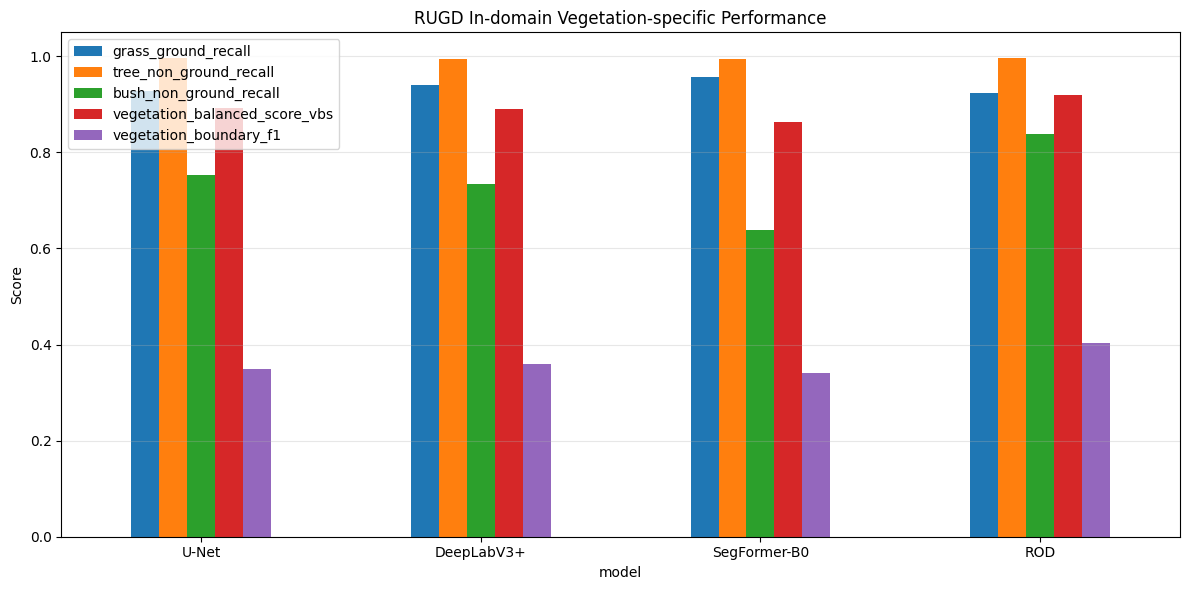

Saved: /content/drive/MyDrive/IRP/05_vegetation_evaluation/01_rugd_indomain/rugd_indomain_vegetation_metrics.png


In [24]:

# 24. Quick comparison plot

plot_df = summary.set_index(
    "model"
)[
    [
        "grass_ground_recall",
        "tree_non_ground_recall",
        "bush_non_ground_recall",
        "vegetation_balanced_score_vbs",
        "vegetation_boundary_f1",
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title(
    "RUGD In-domain Vegetation-specific Performance"
)
ax.grid(
    axis="y",
    alpha=0.3,
)
plt.xticks(
    rotation=0,
)
plt.tight_layout()

plot_path = (
    OUTPUT_ROOT
    / "rugd_indomain_vegetation_metrics.png"
)

plt.savefig(
    plot_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", plot_path)


Automatically selected bush failure scene
Image:               creek_creek_03506.png
Bush pixels:         282585
Mean bush leakage:   0.5255
Leakage range:       0.7374
Selection score:     0.6991


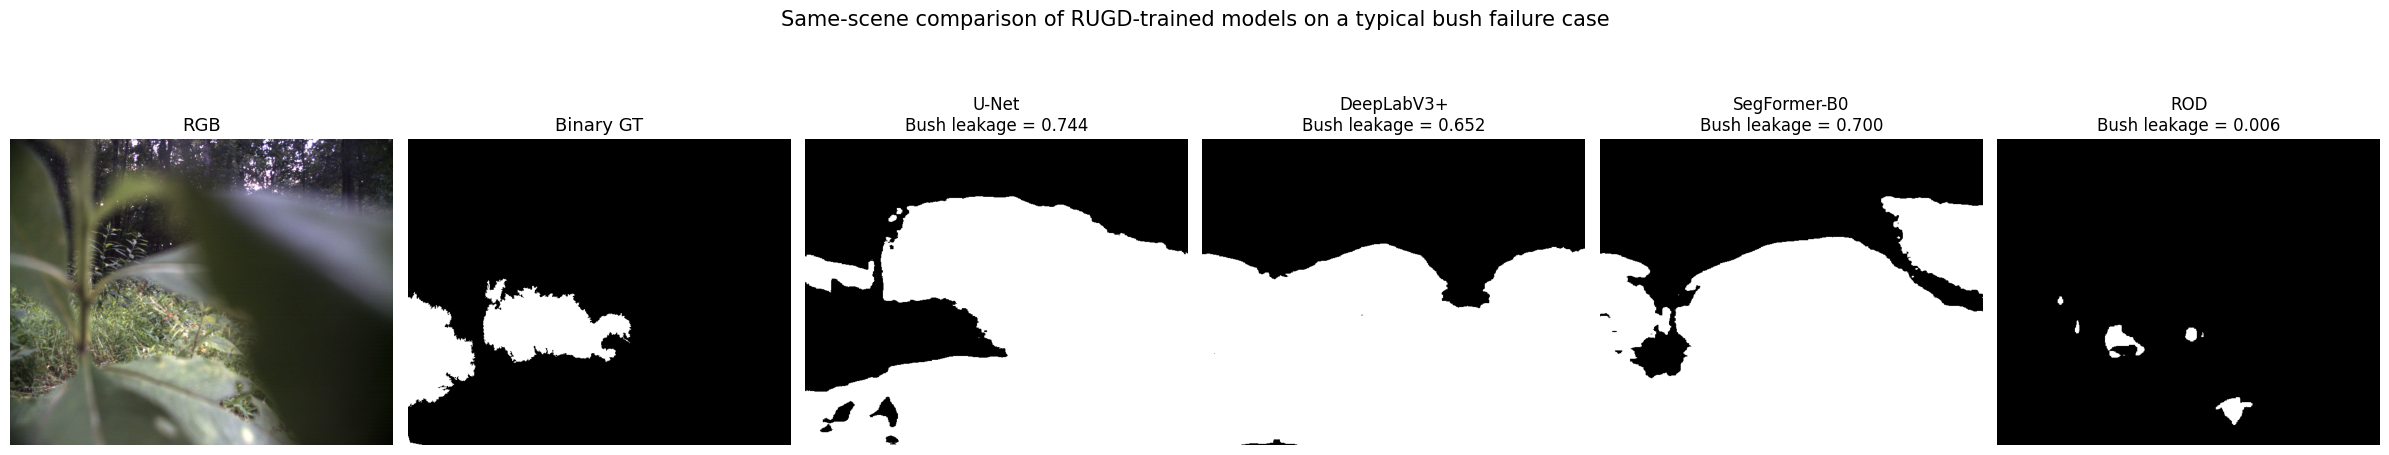


Saved comparison figure:
/content/drive/MyDrive/IRP/05_vegetation_evaluation/01_rugd_indomain/four_model_comparisons/bush_failure_comparison_creek_creek_03506.png


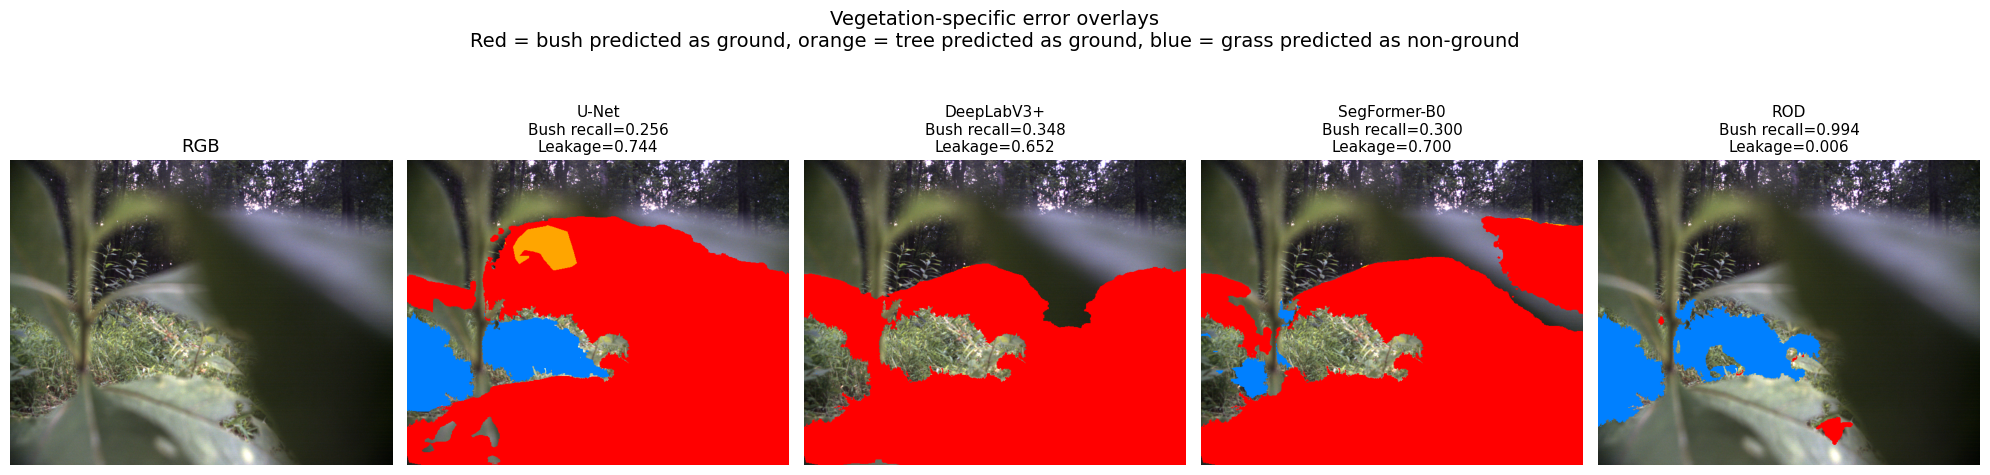


Saved error-overlay figure:
/content/drive/MyDrive/IRP/05_vegetation_evaluation/01_rugd_indomain/four_model_comparisons/bush_failure_errors_creek_creek_03506.png

Per-model metrics for selected scene:


,model,grass_ground_recall,tree_non_ground_recall,bush_non_ground_recall,bush_ground_leakage,per_image_vbs
0,U-Net,0.1976,0.8945,0.2565,0.7435,0.4496
1,DeepLabV3+,0.9999,0.9997,0.3480,0.6520,0.7825
2,SegFormer-B0,0.8941,0.9977,0.2999,0.7001,0.7306
3,ROD,0.0603,1.0000,0.9939,0.0061,0.6847



Saved selected-scene metrics:
/content/drive/MyDrive/IRP/05_vegetation_evaluation/01_rugd_indomain/four_model_comparisons/selected_bush_failure_metrics.csv


In [25]:
# 27. Same-scene four-model comparison + automatic bush failure selection

COMPARISON_DIR = OUTPUT_ROOT / "four_model_comparisons"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "ROD",
]

# ------------------------------------------------------------
# Helper: load one saved prediction
# ------------------------------------------------------------
def load_model_prediction(
    model_name: str,
    processed_name: str,
) -> np.ndarray:

    pred_path = (
        OUTPUT_ROOT
        / "predictions"
        / model_name.replace("/", "_")
        / processed_name
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Prediction not found: {pred_path}"
        )

    return np.array(
        Image.open(pred_path).convert("L")
    ).astype(np.uint8)


# ------------------------------------------------------------
# Helper: create vegetation-specific error overlay
# ------------------------------------------------------------
def make_vegetation_error_overlay(
    rgb: np.ndarray,
    pred: np.ndarray,
    gt_binary: np.ndarray,
    regions: Dict[str, np.ndarray],
) -> np.ndarray:

    overlay = rgb.copy()

    # Bush incorrectly predicted as ground
    bush_error = (
        regions["bush"]
        & (gt_binary == NON_GROUND_ID)
        & (pred == GROUND_ID)
    )

    # Tree incorrectly predicted as ground
    tree_error = (
        regions["tree"]
        & (gt_binary == NON_GROUND_ID)
        & (pred == GROUND_ID)
    )

    # Grass incorrectly predicted as non-ground
    grass_error = (
        regions["grass"]
        & (gt_binary == GROUND_ID)
        & (pred == NON_GROUND_ID)
    )

    # Visualization colours
    # Red    = bush leakage
    # Orange = tree leakage
    # Blue   = grass false non-ground
    overlay[bush_error] = [255, 0, 0]
    overlay[tree_error] = [255, 165, 0]
    overlay[grass_error] = [0, 128, 255]

    return overlay


# ------------------------------------------------------------
# Step 1. Build per-scene cross-model table
# ------------------------------------------------------------
required_cols = [
    "processed_name",
    "model",
    "bush_pixels",
    "bush_ground_leakage",
    "bush_non_ground_recall",
]

missing_cols = [
    c for c in required_cols
    if c not in per_image_results.columns
]

if missing_cols:
    raise KeyError(
        f"Missing required columns in per_image_results: {missing_cols}"
    )


bush_results = per_image_results[
    per_image_results["bush_pixels"] > 0
].copy()


# Keep only scenes evaluated by all four models
model_count_per_scene = (
    bush_results
    .groupby("processed_name")["model"]
    .nunique()
)

common_scenes = model_count_per_scene[
    model_count_per_scene == len(MODEL_ORDER)
].index


bush_results = bush_results[
    bush_results["processed_name"].isin(common_scenes)
].copy()

if len(bush_results) == 0:
    raise RuntimeError(
        "No bush-containing scene has predictions from all four models."
    )


# ------------------------------------------------------------
# Step 2. Aggregate scene difficulty
# ------------------------------------------------------------
scene_stats = (
    bush_results
    .groupby("processed_name")
    .agg(
        bush_pixels=("bush_pixels", "max"),
        mean_bush_leakage=(
            "bush_ground_leakage",
            "mean",
        ),
        max_bush_leakage=(
            "bush_ground_leakage",
            "max",
        ),
        min_bush_leakage=(
            "bush_ground_leakage",
            "min",
        ),
        leakage_std=(
            "bush_ground_leakage",
            "std",
        ),
    )
    .reset_index()
)

scene_stats["leakage_range"] = (
    scene_stats["max_bush_leakage"]
    - scene_stats["min_bush_leakage"]
)

scene_stats["leakage_std"] = (
    scene_stats["leakage_std"]
    .fillna(0)
)


# ------------------------------------------------------------
# Step 3. Filter out tiny bush regions
# ------------------------------------------------------------
#
# Use a relative threshold when possible.
# We prefer scenes where bush is visually substantial.
#
bush_pixel_threshold = max(
    500,
    int(
        scene_stats["bush_pixels"]
        .quantile(0.40)
    )
)

candidate_scenes = scene_stats[
    scene_stats["bush_pixels"]
    >= bush_pixel_threshold
].copy()

if len(candidate_scenes) == 0:
    candidate_scenes = scene_stats.copy()


# ------------------------------------------------------------
# Step 4. Select a representative difficult scene
# ------------------------------------------------------------
#
# The score favours:
# - high average bush leakage
# - meaningful model-to-model difference
# - substantial bush area
#
#
# Normalize quantities to [0, 1]
#
def minmax(series):
    if series.max() == series.min():
        return pd.Series(
            np.zeros(len(series)),
            index=series.index,
        )

    return (
        series - series.min()
    ) / (
        series.max() - series.min()
    )


candidate_scenes[
    "mean_leakage_norm"
] = minmax(
    candidate_scenes[
        "mean_bush_leakage"
    ]
)

candidate_scenes[
    "range_norm"
] = minmax(
    candidate_scenes[
        "leakage_range"
    ]
)

candidate_scenes[
    "bush_area_norm"
] = minmax(
    np.log1p(
        candidate_scenes[
            "bush_pixels"
        ]
    )
)


candidate_scenes[
    "selection_score"
] = (
    0.60
    * candidate_scenes[
        "mean_leakage_norm"
    ]
    +
    0.25
    * candidate_scenes[
        "range_norm"
    ]
    +
    0.15
    * candidate_scenes[
        "bush_area_norm"
    ]
)


candidate_scenes = candidate_scenes.sort_values(
    "selection_score",
    ascending=False,
)

selected_scene = candidate_scenes.iloc[0]
selected_name = selected_scene["processed_name"]


print("=" * 100)
print("Automatically selected bush failure scene")
print("=" * 100)

print(
    f"Image:               {selected_name}"
)

print(
    f"Bush pixels:         "
    f"{int(selected_scene['bush_pixels'])}"
)

print(
    f"Mean bush leakage:   "
    f"{selected_scene['mean_bush_leakage']:.4f}"
)

print(
    f"Leakage range:       "
    f"{selected_scene['leakage_range']:.4f}"
)

print(
    f"Selection score:     "
    f"{selected_scene['selection_score']:.4f}"
)


# ------------------------------------------------------------
# Step 5. Get original image and GT
# ------------------------------------------------------------
scene_rows = bush_results[
    bush_results["processed_name"]
    == selected_name
].copy()

reference_row = scene_rows.iloc[0]

rgb = read_rgb(
    Path(
        reference_row["image_path"]
    )
)

semantic_rgb = read_rgb(
    Path(
        reference_row[
            "original_rgb_mask_path"
        ]
    )
)


# Use original RGB image resolution
target_shape = rgb.shape[:2]

semantic_rgb = resize_nearest(
    semantic_rgb,
    target_shape,
)

gt_binary = rugd_rgb_to_binary(
    semantic_rgb
)

regions = extract_vegetation_regions(
    semantic_rgb
)


# ------------------------------------------------------------
# Step 6. Prepare predictions for all four models
# ------------------------------------------------------------
predictions = {}

for model_name in MODEL_ORDER:

    model_row = scene_rows[
        scene_rows["model"]
        == model_name
    ]

    if len(model_row) != 1:
        raise RuntimeError(
            f"Expected one result for "
            f"{model_name} on {selected_name}, "
            f"found {len(model_row)}"
        )

    pred = load_model_prediction(
        model_name,
        selected_name,
    )

    if pred.shape != target_shape:
        pred = resize_nearest(
            pred,
            target_shape,
        )

    predictions[model_name] = pred


# ------------------------------------------------------------
# Step 7. Figure A:
# RGB | GT | U-Net | DeepLabV3+ | SegFormer-B0 | ROD
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    6,
    figsize=(24, 5),
)

axes[0].imshow(rgb)
axes[0].set_title(
    "RGB",
    fontsize=13,
)


axes[1].imshow(
    gt_binary,
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[1].set_title(
    "Binary GT",
    fontsize=13,
)


for col_idx, model_name in enumerate(
    MODEL_ORDER,
    start=2,
):

    model_row = scene_rows[
        scene_rows["model"]
        == model_name
    ].iloc[0]

    axes[col_idx].imshow(
        predictions[model_name],
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    leakage = model_row[
        "bush_ground_leakage"
    ]

    axes[col_idx].set_title(
        f"{model_name}\n"
        f"Bush leakage = {leakage:.3f}",
        fontsize=12,
    )


for ax in axes:
    ax.axis("off")


fig.suptitle(
    "Same-scene comparison of RUGD-trained models on a typical bush failure case",
    fontsize=15,
    y=1.03,
)

plt.tight_layout()


comparison_path = (
    COMPARISON_DIR
    / f"bush_failure_comparison_{selected_name}"
)

plt.savefig(
    comparison_path,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "\nSaved comparison figure:"
)
print(
    comparison_path
)


# ------------------------------------------------------------
# Step 8. Figure B:
# Error overlays for the same four models
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 5),
)

axes[0].imshow(rgb)
axes[0].set_title(
    "RGB",
    fontsize=13,
)

axes[0].axis("off")


for idx, model_name in enumerate(
    MODEL_ORDER,
    start=1,
):

    error_overlay = (
        make_vegetation_error_overlay(
            rgb,
            predictions[model_name],
            gt_binary,
            regions,
        )
    )

    model_row = scene_rows[
        scene_rows["model"]
        == model_name
    ].iloc[0]

    bush_recall = model_row[
        "bush_non_ground_recall"
    ]

    bush_leakage = model_row[
        "bush_ground_leakage"
    ]

    axes[idx].imshow(
        error_overlay
    )

    axes[idx].set_title(
        f"{model_name}\n"
        f"Bush recall={bush_recall:.3f}\n"
        f"Leakage={bush_leakage:.3f}",
        fontsize=11,
    )

    axes[idx].axis("off")


fig.suptitle(
    "Vegetation-specific error overlays\n"
    "Red = bush predicted as ground, "
    "orange = tree predicted as ground, "
    "blue = grass predicted as non-ground",
    fontsize=14,
    y=1.05,
)

plt.tight_layout()


error_path = (
    COMPARISON_DIR
    / f"bush_failure_errors_{selected_name}"
)

plt.savefig(
    error_path,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

print(
    "\nSaved error-overlay figure:"
)
print(
    error_path
)


# ------------------------------------------------------------
# Step 9. Print per-model metrics for selected scene
# ------------------------------------------------------------
selected_metrics = (
    scene_rows[
        [
            "model",
            "grass_ground_recall",
            "tree_non_ground_recall",
            "bush_non_ground_recall",
            "bush_ground_leakage",
            "per_image_vbs",
        ]
    ]
    .set_index("model")
    .reindex(MODEL_ORDER)
    .reset_index()
)

print(
    "\nPer-model metrics for selected scene:"
)

display(
    selected_metrics.style.format({
        "grass_ground_recall": "{:.4f}",
        "tree_non_ground_recall": "{:.4f}",
        "bush_non_ground_recall": "{:.4f}",
        "bush_ground_leakage": "{:.4f}",
        "per_image_vbs": "{:.4f}",
    })
)


# ------------------------------------------------------------
# Step 10. Save selected-scene metrics
# ------------------------------------------------------------
selected_metrics_path = (
    COMPARISON_DIR
    / "selected_bush_failure_metrics.csv"
)

selected_metrics.to_csv(
    selected_metrics_path,
    index=False,
)

candidate_scenes.to_csv(
    COMPARISON_DIR
    / "bush_failure_scene_ranking.csv",
    index=False,
)

print(
    "\nSaved selected-scene metrics:"
)
print(
    selected_metrics_path
)

In [30]:
# 27. Select 5 successful scenes + 5 representative bush failure scenes
#     and generate same-scene four-model comparison figures
from matplotlib.patches import Patch
COMPARISON_DIR = OUTPUT_ROOT / "four_model_comparisons"
SUCCESS_DIR = COMPARISON_DIR / "success_cases"
FAILURE_DIR = COMPARISON_DIR / "failure_cases"

SUCCESS_DIR.mkdir(parents=True, exist_ok=True)
FAILURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "ROD",
]

NUM_SUCCESS = 5
NUM_FAILURE = 5

# Avoid selecting scenes with only a tiny amount of bush.
MIN_BUSH_PIXELS = 500


# ============================================================
# 1. Helper: load saved model prediction
# ============================================================

def load_model_prediction(
    model_name: str,
    processed_name: str,
) -> np.ndarray:

    pred_path = (
        OUTPUT_ROOT
        / "predictions"
        / model_name.replace("/", "_")
        / processed_name
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Prediction not found: {pred_path}"
        )

    return np.array(
        Image.open(pred_path).convert("L")
    ).astype(np.uint8)


# ============================================================
# 2. Helper: vegetation error overlay
# ============================================================

def make_vegetation_error_overlay(
    rgb: np.ndarray,
    pred: np.ndarray,
    gt_binary: np.ndarray,
    regions: Dict[str, np.ndarray],
) -> np.ndarray:

    overlay = rgb.copy()

    # Bush obstacle incorrectly predicted as ground
    bush_error = (
        regions["bush"]
        & (gt_binary == NON_GROUND_ID)
        & (pred == GROUND_ID)
    )

    # Tree incorrectly predicted as ground
    tree_error = (
        regions["tree"]
        & (gt_binary == NON_GROUND_ID)
        & (pred == GROUND_ID)
    )

    # Grass incorrectly predicted as non-ground
    grass_error = (
        regions["grass"]
        & (gt_binary == GROUND_ID)
        & (pred == NON_GROUND_ID)
    )

    # Visualization only:
    # red    = bush -> ground
    # orange = tree -> ground
    # blue   = grass -> non-ground
    overlay[bush_error] = [255, 0, 0]
    overlay[tree_error] = [255, 165, 0]
    overlay[grass_error] = [0, 128, 255]

    return overlay


# ============================================================
# 3. Prepare scenes available for ALL FOUR models
# ============================================================

required_cols = [
    "processed_name",
    "model",
    "bush_pixels",
    "grass_ground_recall",
    "tree_non_ground_recall",
    "bush_non_ground_recall",
    "bush_ground_leakage",
    "per_image_vbs",
]

missing_cols = [
    c for c in required_cols
    if c not in per_image_results.columns
]

if missing_cols:
    raise KeyError(
        f"Missing columns in per_image_results: {missing_cols}"
    )


# We use scenes containing a meaningful bush region,
# because the main failure mode of interest is bush leakage.
scene_results = per_image_results[
    per_image_results["bush_pixels"] >= MIN_BUSH_PIXELS
].copy()


# Keep only scenes for which all 4 models have results.
model_count = (
    scene_results
    .groupby("processed_name")["model"]
    .nunique()
)

common_scene_names = model_count[
    model_count == len(MODEL_ORDER)
].index

scene_results = scene_results[
    scene_results["processed_name"].isin(common_scene_names)
].copy()

if len(scene_results) == 0:
    raise RuntimeError(
        "No scenes with sufficient bush pixels were evaluated by all four models."
    )

print(
    f"Candidate scenes with >= {MIN_BUSH_PIXELS} bush pixels "
    f"and all four model predictions: "
    f"{scene_results['processed_name'].nunique()}"
)


# ============================================================
# 4. Compute scene-level statistics across four models
# ============================================================

scene_stats = (
    scene_results
    .groupby("processed_name")
    .agg(
        bush_pixels=(
            "bush_pixels",
            "max",
        ),

        mean_grass_recall=(
            "grass_ground_recall",
            "mean",
        ),

        mean_tree_recall=(
            "tree_non_ground_recall",
            "mean",
        ),

        mean_bush_recall=(
            "bush_non_ground_recall",
            "mean",
        ),

        mean_bush_leakage=(
            "bush_ground_leakage",
            "mean",
        ),

        mean_vbs=(
            "per_image_vbs",
            "mean",
        ),

        min_vbs=(
            "per_image_vbs",
            "min",
        ),

        max_vbs=(
            "per_image_vbs",
            "max",
        ),

        max_bush_leakage=(
            "bush_ground_leakage",
            "max",
        ),

        min_bush_leakage=(
            "bush_ground_leakage",
            "min",
        ),

        std_bush_leakage=(
            "bush_ground_leakage",
            "std",
        ),
    )
    .reset_index()
)


scene_stats["std_bush_leakage"] = (
    scene_stats["std_bush_leakage"]
    .fillna(0)
)

scene_stats["bush_leakage_range"] = (
    scene_stats["max_bush_leakage"]
    - scene_stats["min_bush_leakage"]
)


# ============================================================
# 5. Helper: min-max normalize
# ============================================================

def minmax(series):

    series = series.astype(float)

    if series.max() == series.min():
        return pd.Series(
            np.zeros(len(series)),
            index=series.index,
        )

    return (
        series - series.min()
    ) / (
        series.max() - series.min()
    )


scene_stats["bush_area_norm"] = minmax(
    np.log1p(
        scene_stats["bush_pixels"]
    )
)

scene_stats["mean_vbs_norm"] = minmax(
    scene_stats["mean_vbs"]
)

scene_stats["mean_leakage_norm"] = minmax(
    scene_stats["mean_bush_leakage"]
)

scene_stats["leakage_range_norm"] = minmax(
    scene_stats["bush_leakage_range"]
)


# ============================================================
# 6. SUCCESS score
# ============================================================
#
# Successful scene should:
#   - have high vegetation performance overall
#   - have low bush leakage
#   - contain a sufficiently visible bush region
#
# Mean VBS is dominant.
#

scene_stats["success_score"] = (
    0.60
    * scene_stats["mean_vbs_norm"]

    +

    0.25
    * (1.0 - scene_stats["mean_leakage_norm"])

    +

    0.15
    * scene_stats["bush_area_norm"]
)


# ============================================================
# 7. FAILURE score
# ============================================================
#
# Representative failure should:
#   - have high mean bush leakage
#   - show some model-to-model variation
#   - contain a visually meaningful bush region
#

scene_stats["failure_score"] = (
    0.60
    * scene_stats["mean_leakage_norm"]

    +

    0.25
    * scene_stats["leakage_range_norm"]

    +

    0.15
    * scene_stats["bush_area_norm"]
)


# ============================================================
# 8. Select top-5 success and top-5 failure
# ============================================================

success_cases = (
    scene_stats
    .sort_values(
        "success_score",
        ascending=False,
    )
    .head(NUM_SUCCESS)
    .copy()
)


failure_candidates = (
    scene_stats
    [
        ~scene_stats["processed_name"].isin(
            success_cases["processed_name"]
        )
    ]
    .copy()
)

failure_cases = (
    failure_candidates
    .sort_values(
        "failure_score",
        ascending=False,
    )
    .head(NUM_FAILURE)
    .copy()
)


print("\n" + "=" * 100)
print("SELECTED SUCCESS CASES")
print("=" * 100)

display(
    success_cases[
        [
            "processed_name",
            "bush_pixels",
            "mean_vbs",
            "mean_bush_recall",
            "mean_bush_leakage",
            "success_score",
        ]
    ].reset_index(drop=True)
)


print("\n" + "=" * 100)
print("SELECTED FAILURE CASES")
print("=" * 100)

display(
    failure_cases[
        [
            "processed_name",
            "bush_pixels",
            "mean_vbs",
            "mean_bush_recall",
            "mean_bush_leakage",
            "bush_leakage_range",
            "failure_score",
        ]
    ].reset_index(drop=True)
)


# ============================================================
# 9. Function to generate one same-scene comparison figure
# ============================================================

def plot_four_model_scene(
    processed_name: str,
    case_type: str,
    rank: int,
):

    scene_rows = scene_results[
        scene_results["processed_name"]
        == processed_name
    ].copy()


    if len(scene_rows) != len(MODEL_ORDER):
        raise RuntimeError(
            f"{processed_name}: expected {len(MODEL_ORDER)} model rows, "
            f"found {len(scene_rows)}"
        )


    reference_row = scene_rows.iloc[0]


    # --------------------------------------------------------
    # Load RGB + semantic ground truth
    # --------------------------------------------------------

    rgb = read_rgb(
        Path(
            reference_row["image_path"]
        )
    )

    semantic_rgb = read_rgb(
        Path(
            reference_row[
                "original_rgb_mask_path"
            ]
        )
    )


    target_shape = rgb.shape[:2]


    semantic_rgb = resize_nearest(
        semantic_rgb,
        target_shape,
    )


    gt_binary = rugd_rgb_to_binary(
        semantic_rgb
    )


    regions = extract_vegetation_regions(
        semantic_rgb
    )


    # --------------------------------------------------------
    # Load predictions
    # --------------------------------------------------------

    predictions = {}

    for model_name in MODEL_ORDER:

        pred = load_model_prediction(
            model_name,
            processed_name,
        )

        if pred.shape != target_shape:
            pred = resize_nearest(
                pred,
                target_shape,
            )

        predictions[model_name] = pred


    # ========================================================
    # COMBINED FIGURE:
    #
    # Row 1:
    # RGB | Binary GT | U-Net | DeepLabV3+ | SegFormer-B0 | ROD
    #
    # Row 2:
    #     |           | U-Net error | DeepLab error |
    #                   SegFormer error | ROD error
    # ========================================================

    fig, axes = plt.subplots(
        2,
        6,
        figsize=(24, 10),
    )


    # ========================================================
    # ROW 1
    # ========================================================

    # --------------------------------------------------------
    # RGB
    # --------------------------------------------------------

    axes[0, 0].imshow(rgb)

    axes[0, 0].set_title(
        "RGB",
        fontsize=18,
        fontweight="bold",
    )

    axes[0, 0].axis("off")


    # --------------------------------------------------------
    # Binary GT
    # --------------------------------------------------------

    axes[0, 1].imshow(
        gt_binary,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[0, 1].set_title(
        "Binary GT",
        fontsize=18,
        fontweight="bold",
    )

    axes[0, 1].axis("off")


    # --------------------------------------------------------
    # Model predictions
    # --------------------------------------------------------

    for col_idx, model_name in enumerate(
        MODEL_ORDER,
        start=2,
    ):

        axes[0, col_idx].imshow(
            predictions[model_name],
            cmap="gray",
            vmin=0,
            vmax=1,
        )

        # Model name stays above the image
        axes[0, col_idx].set_title(
            f"{model_name}",
            fontsize=18,
            fontweight="bold",
        )

        axes[0, col_idx].axis("off")


    # ========================================================
    # ROW 2
    # ========================================================

    # First two positions intentionally left blank
    axes[1, 0].axis("off")
    axes[1, 1].axis("off")


    # --------------------------------------------------------
    # Vegetation error overlays
    # --------------------------------------------------------

    for col_idx, model_name in enumerate(
        MODEL_ORDER,
        start=2,
    ):

        error_overlay = (
            make_vegetation_error_overlay(
                rgb,
                predictions[model_name],
                gt_binary,
                regions,
            )
        )


        model_row = scene_rows[
            scene_rows["model"]
            == model_name
        ].iloc[0]


        axes[1, col_idx].imshow(
            error_overlay
        )


        # No duplicated model title in the second row
        # axes[1, col_idx].axis("off")


        # ----------------------------------------------------
        # Bush recall + leakage BELOW the corresponding image
        # ----------------------------------------------------

        axes[1, col_idx].set_xlabel(
            f"Bush R={model_row['bush_non_ground_recall']:.3f}\n"
            f"Leak={model_row['bush_ground_leakage']:.3f}",
            fontsize=18,
            labelpad=10,
        )


    # ========================================================
    # Legend
    # ========================================================

    legend_elements = [
        Patch(
          facecolor="black",
          edgecolor="black",
          label="Correct non-ground",
    ),

        Patch(
          facecolor="white",
          edgecolor="black",
          label="Correct ground",
    ),
        Patch(
            facecolor="red",
            label="Bush → Ground",
        ),
        Patch(
            facecolor="orange",
            label="Tree → Ground",
        ),
        Patch(
            facecolor="dodgerblue",
            label="Grass → Non-ground",
        ),
    ]


    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=5,
        fontsize=18,
        frameon=False,
        bbox_to_anchor=(
            0.5,
            0.01,
        ),
    )


    # ========================================================
    # Overall title
    # ========================================================

    case_label = (
        "Successful Vegetation Case"
        if case_type == "success"
        else "Representative Bush Failure"
    )


    fig.suptitle(
        f"{case_label} #{rank}: {processed_name}",
        fontsize=18,
        fontweight="bold",
        y=0.98,
    )


    # ========================================================
    # Layout
    # ========================================================

    plt.tight_layout(
        rect=[
            0,
            0.08,
            1,
            0.95,
        ]
    )


    # ========================================================
    # Save
    # ========================================================

    save_dir = (
        SUCCESS_DIR
        if case_type == "success"
        else FAILURE_DIR
    )


    combined_path = (
        save_dir
        / f"{rank:02d}_{processed_name}_combined.png"
    )


    plt.savefig(
        combined_path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


    return {
      "case_type": case_type,
      "rank": rank,
      "processed_name": processed_name,
      "combined_figure": str(
          combined_path
      ),
    }


# ============================================================
# 10. Generate five successful cases
# ============================================================

saved_cases = []

print("\n" + "=" * 100)
print("GENERATING 5 SUCCESSFUL CASES")
print("=" * 100)


for rank, (_, case_row) in enumerate(
    success_cases.iterrows(),
    start=1,
):

    processed_name = case_row[
        "processed_name"
    ]

    print(
        f"\nSuccess {rank}/{NUM_SUCCESS}: "
        f"{processed_name}"
    )

    saved_cases.append(
        plot_four_model_scene(
            processed_name,
            case_type="success",
            rank=rank,
        )
    )


# ============================================================
# 11. Generate five representative failures
# ============================================================

print("\n" + "=" * 100)
print("GENERATING 5 FAILURE CASES")
print("=" * 100)


for rank, (_, case_row) in enumerate(
    failure_cases.iterrows(),
    start=1,
):

    processed_name = case_row[
        "processed_name"
    ]

    print(
        f"\nFailure {rank}/{NUM_FAILURE}: "
        f"{processed_name}"
    )

    saved_cases.append(
        plot_four_model_scene(
            processed_name,
            case_type="failure",
            rank=rank,
        )
    )


# ============================================================
# 12. Save ranking and selected-case information
# ============================================================

success_cases.to_csv(
    COMPARISON_DIR
    / "selected_5_success_cases.csv",
    index=False,
)

failure_cases.to_csv(
    COMPARISON_DIR
    / "selected_5_failure_cases.csv",
    index=False,
)

scene_stats.sort_values(
    "failure_score",
    ascending=False,
).to_csv(
    COMPARISON_DIR
    / "all_scene_rankings.csv",
    index=False,
)

saved_cases_df = pd.DataFrame(
    saved_cases
)

saved_cases_df.to_csv(
    COMPARISON_DIR
    / "selected_case_figure_paths.csv",
    index=False,
)


print("\n" + "=" * 100)
print("DONE")
print("=" * 100)

print(
    "\nSuccess cases:"
)
print(
    SUCCESS_DIR
)

print(
    "\nFailure cases:"
)
print(
    FAILURE_DIR
)

print(
    "\nCase rankings saved to:"
)
print(
    COMPARISON_DIR
)

Output hidden; open in https://colab.research.google.com to view.


## Main output

For the dissertation table, use:

`rugd_indomain_vegetation_summary.csv`

The key columns are:

- `grass_ground_recall`
- `tree_non_ground_recall`
- `bush_non_ground_recall`
- `bush_ground_leakage`
- `vegetation_balanced_score_vbs`
- `vegetation_boundary_f1`

The per-image CSV is intended for later qualitative failure-case selection.
